In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip install torchinfo

## Conditional GAN

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device = 'cuda:0'

torch.__version__

'2.8.0+cu126'

- model params

In [4]:
BUFFER_SIZE = 60000
BATCH_SIZE = 600
label_dim=10    # class_num.
noise_dim = 90  # latent vector dim.
IN_PUT_DIM=label_dim+noise_dim  # 100
num_examples_to_generate = 16
IMG_SHAPE=(28,28,1)

### Dataset 준비

In [5]:
import torchvision.transforms as v2
from torchvision.datasets import FashionMNIST, MNIST

class Normalize(object):
    def __call__(self, sample):
        sample = np.array(sample)
        image = (sample - 127.5) / 127.5
        image = torch.FloatTensor(image).unsqueeze(dim=0)
        return image #(1,28,28)

class Onehot(object):
    def __call__(self, sample):
        target = torch.eye(10)[sample]  #(b,10)
        return target

# Normalize data to [-1 ~ 1]
mnist_transform = v2.Compose([Normalize()])
target_transform = v2.Compose([Onehot()])

# download path 정의
download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=mnist_transform, train=True,
                      download=True, target_transform=target_transform)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                     download=True, target_transform=target_transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [6]:
ps(train_dataset[0][0]),train_dataset[0][1]

[] Shapetorch.Size([1, 28, 28])


(None, tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]))

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


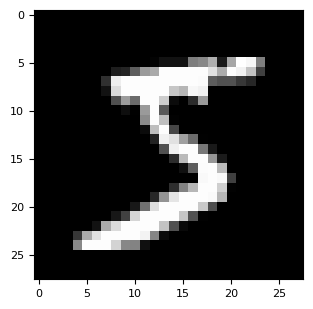

In [7]:
plt.imshow(train_dataset[0][0][0], cmap='gray') # 첫번째 이미지와
print(train_dataset[0][1])                      # 그 label(one-hot coding)

In [15]:
train_dataloader = DataLoader(train_dataset, BATCH_SIZE, True, num_workers=4)
test_dataloader = DataLoader(test_dataset, BATCH_SIZE, False, num_workers=4)

### Model define

- Generator 생성 함수

In [8]:
# Generator model
class Generator(nn.Module):
    def __init__(self, input_dim):
        super(Generator, self).__init__()
        self.generator = nn.Sequential(
            nn.Linear(input_dim, 256 * 7 * 7, bias=False),
            nn.Unflatten(1, (256, 7, 7)),
            nn.BatchNorm2d(256,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 5, 1,
                          padding=2, bias=False),
            nn.BatchNorm2d(128,momentum=0.8), #(128,7,7)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 5, 2,
                         padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(64,momentum=0.8),  #(64,14,14)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 1, 5, 2,
                         padding=2, output_padding=1, bias=True),
            nn.Tanh() )         #(1,28,28)

    def forward(self, z, c):
        c = c.to(device)
        inputs = torch.cat([z, c], dim=1)
        out = self.generator(inputs)
        return out

z_vector = torch.randn((BATCH_SIZE, noise_dim), device=device)
generator = Generator(IN_PUT_DIM).to(device)
summary(generator, input_size=[(BATCH_SIZE, noise_dim), (BATCH_SIZE, label_dim)])

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [600, 1, 28, 28]          --
├─Sequential: 1-1                        [600, 1, 28, 28]          --
│    └─Linear: 2-1                       [600, 12544]              1,254,400
│    └─Unflatten: 2-2                    [600, 256, 7, 7]          --
│    └─BatchNorm2d: 2-3                  [600, 256, 7, 7]          512
│    └─LeakyReLU: 2-4                    [600, 256, 7, 7]          --
│    └─ConvTranspose2d: 2-5              [600, 128, 7, 7]          819,200
│    └─BatchNorm2d: 2-6                  [600, 128, 7, 7]          256
│    └─LeakyReLU: 2-7                    [600, 128, 7, 7]          --
│    └─ConvTranspose2d: 2-8              [600, 64, 14, 14]         204,800
│    └─BatchNorm2d: 2-9                  [600, 64, 14, 14]         128
│    └─LeakyReLU: 2-10                   [600, 64, 14, 14]         --
│    └─ConvTranspose2d: 2-11             [600, 1, 28, 28]        

- Discriminator 생성 함수

In [9]:
IMG_SHAPE

(28, 28, 1)

In [10]:
# Discriminator model
class Discriminator(nn.Module):
    def __init__(self, label_dim):
        super(Discriminator, self).__init__()
        self.categoryLinear = nn.Sequential(
            nn.Linear(label_dim, 28*28),
            nn.Unflatten(1, (1, 28, 28)) )
        self.discriminator = nn.Sequential(
            nn.Conv2d(2, 64, 5, 2, padding=2), #(64,14,14)
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, 5, 2, padding=2),#(128,7,7)
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Flatten(),                       #(6272,)
            nn.Linear(128*7*7, 1),
            nn.Sigmoid() )

    def forward(self, x, c):                   #x:(1,28,28)
        cat_out = self.categoryLinear(c)       #(1,28,28)
        inputs = torch.cat([x, cat_out], dim=1)#(2,28,28)
        out = self.discriminator(inputs)
        return out

discriminator = Discriminator(label_dim).to(device)
summary(discriminator, input_size=[(BATCH_SIZE, 1, 28, 28), (BATCH_SIZE, label_dim)])

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [600, 1]                  --
├─Sequential: 1-1                        [600, 1, 28, 28]          --
│    └─Linear: 2-1                       [600, 784]                8,624
│    └─Unflatten: 2-2                    [600, 1, 28, 28]          --
├─Sequential: 1-2                        [600, 1]                  --
│    └─Conv2d: 2-3                       [600, 64, 14, 14]         3,264
│    └─LeakyReLU: 2-4                    [600, 64, 14, 14]         --
│    └─Dropout: 2-5                      [600, 64, 14, 14]         --
│    └─Conv2d: 2-6                       [600, 128, 7, 7]          204,928
│    └─LeakyReLU: 2-7                    [600, 128, 7, 7]          --
│    └─Dropout: 2-8                      [600, 128, 7, 7]          --
│    └─Flatten: 2-9                      [600, 6272]               --
│    └─Linear: 2-10                      [600, 1]                  6,273
│

### Model들 생성 및 학습조건 설정

- 이미지 생성 및 저장 함수

In [11]:
def generate_and_save_images(gen, epoch):
    r, c = 10, 10
    fig = plt.figure(figsize=(5,5))
    plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
    for i in range(c):
        sampled_noise, _ = generator_input(c) # Fake label은 버리고
        # 0~9 까지 새로운 label생성
        new_label = np.eye(r, 10)[
          np.full(fill_value=i, shape=(r))] # 10개씩 준비
        # z와 new_label 10개를 입력으로 이미지 추론
        gen_imgs = generator(torch.FloatTensor(sampled_noise).to(device), torch.FloatTensor(new_label).to(device))###
        gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
        for j in range(r):
            ax = fig.add_subplot(r, c, j * r + i + 1)
            ax.imshow(gen_imgs.cpu().detach().numpy()[j,0, :, :], cmap=plt.cm.bone)
            ax.xaxis.set_ticks([])
            ax.yaxis.set_ticks([])
    plt.tight_layout()
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

- Generator 입력으로 들어가는 z_vetor와 Fake label생성

In [12]:
def generator_input(batch_size):
    # Generator inputs
    sampled_noise = torch.randn(batch_size, noise_dim) #(b,90)
    sampled_labels = torch.randint(10, (batch_size,))  #(b,)
    sampled_labels = torch.eye(10)[sampled_labels]  #(b,10)
    return sampled_noise, sampled_labels #((b,90),(b,10))

ps(generator_input(2)[1]) #labels(b,10)

[] Shapetorch.Size([2, 10])


In [13]:
lr = 2e-4
loss_function = nn.BCELoss()

generator = generator.to(device)
discriminator = discriminator.to(device)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr)

### Training

Epoch: 0 Loss D.: 0.02469727396965027
Epoch: 0 Loss G.: 4.148926258087158


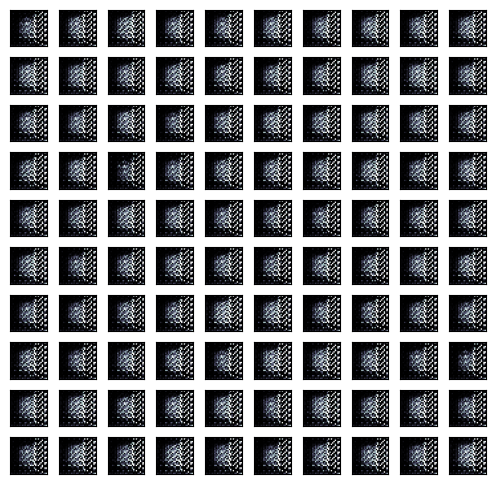

Epoch: 10 Loss D.: 0.08287195861339569
Epoch: 10 Loss G.: 4.110201835632324


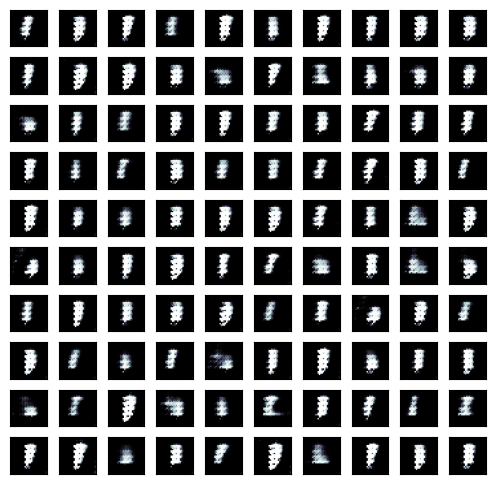

Epoch: 20 Loss D.: 0.5807328224182129
Epoch: 20 Loss G.: 1.8676975965499878


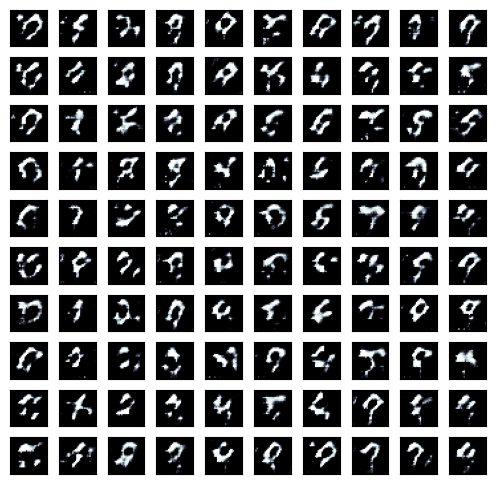

Epoch: 30 Loss D.: 0.5420602560043335
Epoch: 30 Loss G.: 1.322400450706482


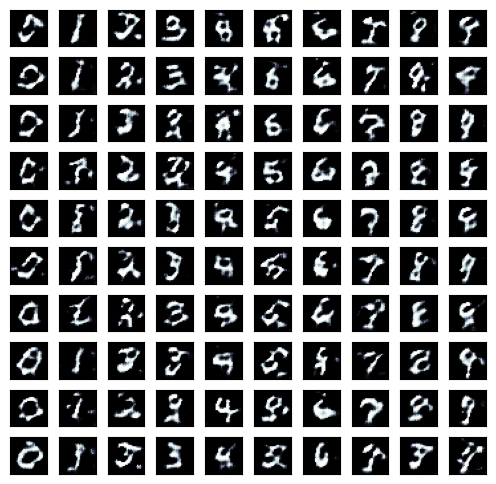

Epoch: 40 Loss D.: 0.3230283260345459
Epoch: 40 Loss G.: 1.8791565895080566


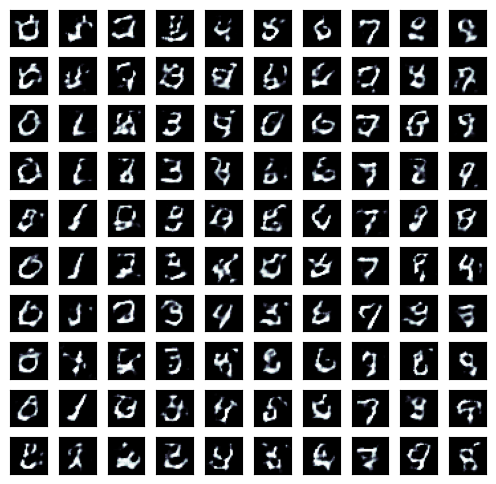

Epoch: 50 Loss D.: 0.4227360785007477
Epoch: 50 Loss G.: 1.683724284172058


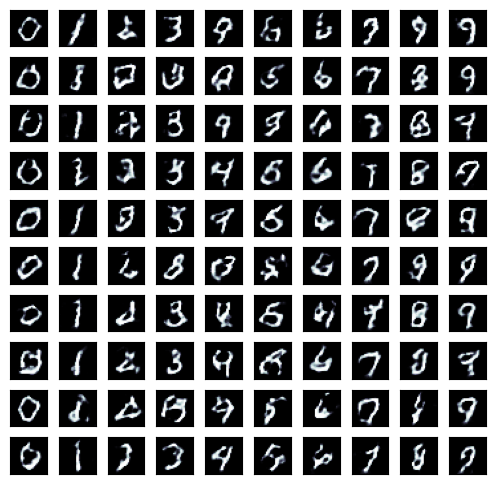

In [ ]:
%%time
EPOCHS = 100
# generator.train()
# discriminator.train()
for epoch in range(EPOCHS):
    for image_batch, real_label in train_dataloader:
        image_batch = image_batch.to(device)
        real_label = real_label.to(device)
        noise, f_labels = generator_input(BATCH_SIZE)
        noise, f_labels = noise.to(device), f_labels.to(device)
        f_img = generator(noise, f_labels)
        con_imgs = torch.cat([image_batch,f_img])
        con_labels = torch.cat([real_label,f_labels])
        y_r = torch.ones((BATCH_SIZE,1)).to(device)
        y_f = torch.zeros((BATCH_SIZE,1)).to(device)
        con_y = torch.cat([y_r,y_f])
        # Discriminator
        discriminator.zero_grad()
        out_dis = discriminator(con_imgs, con_labels)
        loss_d = loss_function(out_dis, con_y)
        loss_d.backward()
        optimizer_d.step()
        # Generator
        noise, f_labels = generator_input(BATCH_SIZE)
        noise, f_labels = noise.to(device), f_labels.to(device)
        generator.zero_grad()
        f_img = generator(noise, f_labels)
        out_dis = discriminator(f_img, f_labels)
        loss_g = loss_function(out_dis, y_r)
        loss_g.backward()
        optimizer_g.step()

    # Show loss
    if epoch % 10 == 0:  #10 #학습된 gen.의 성능 확인
        print(f"Epoch: {epoch} Loss D.: {loss_d}")
        print(f"Epoch: {epoch} Loss G.: {loss_g}")
        generate_and_save_images(generator, epoch)

# Wall time: 29min 24s

Epoch: 0 Loss D.: 0.5318223237991333
Epoch: 0 Loss G.: 1.1607205867767334  
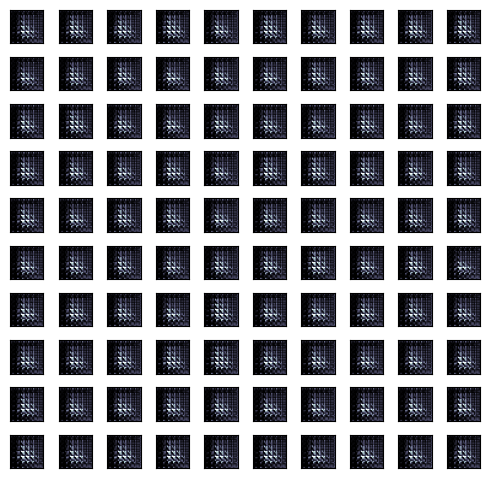

Epoch: 10 Loss D.: 0.30561184883117676
Epoch: 10 Loss G.: 2.70947265625  
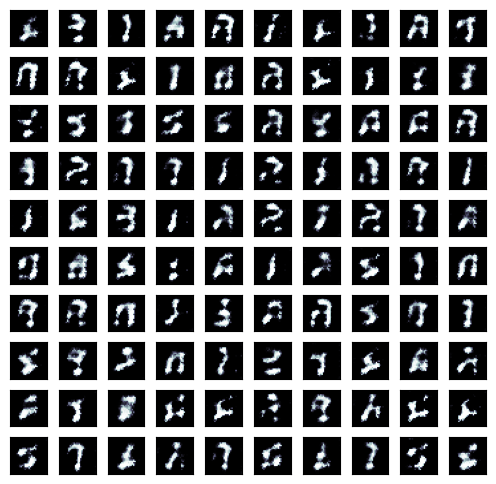


Epoch: 20 Loss D.: 0.06620080024003983
Epoch: 20 Loss G.: 5.21453332901001  
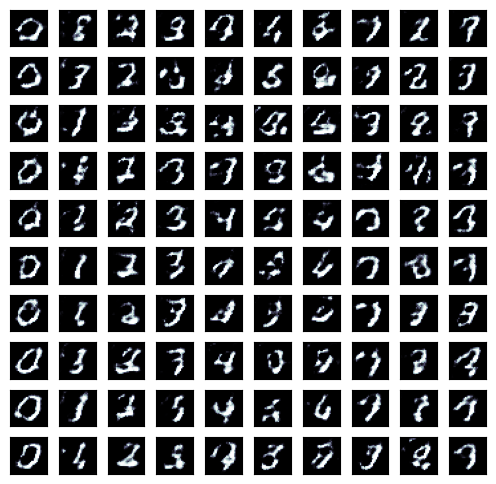

Epoch: 30 Loss D.: 0.10764046013355255
Epoch: 30 Loss G.: 4.0651164054870605  
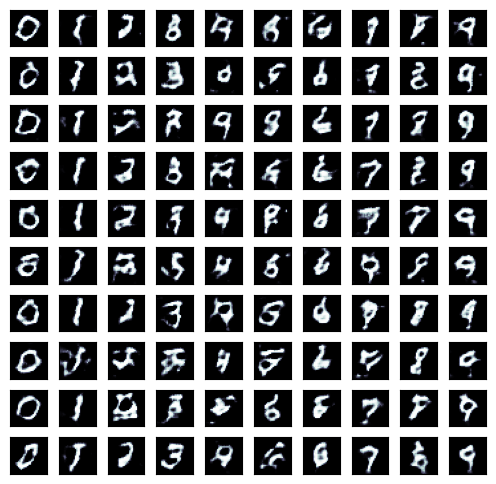

Epoch: 40 Loss D.: 0.1742338389158249
Epoch: 40 Loss G.: 3.8502840995788574  
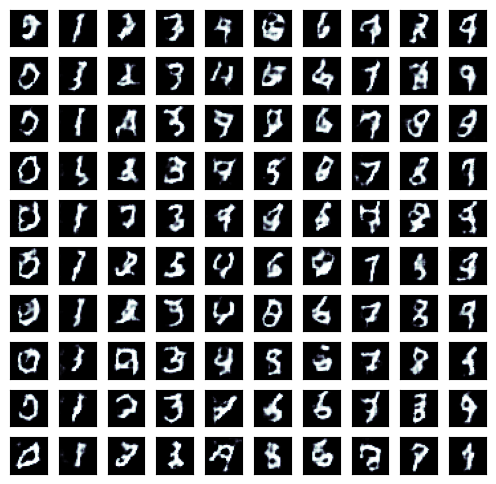

Epoch: 50 Loss D.: 0.259223997592926
Epoch: 50 Loss G.: 2.6712615489959717  
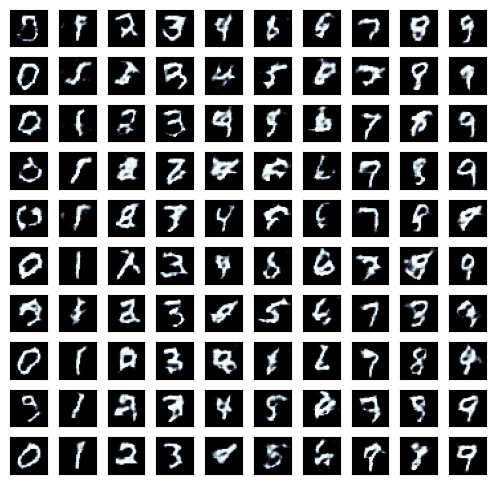

Epoch: 60 Loss D.: 0.37030720710754395
Epoch: 60 Loss G.: 2.0540883541107178  
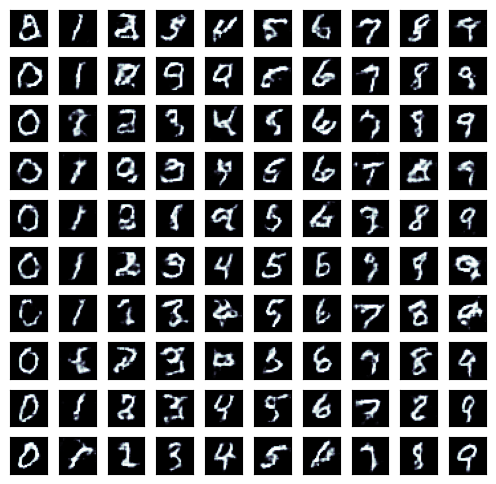

Epoch: 70 Loss D.: 0.45979517698287964
Epoch: 70 Loss G.: 1.6760761737823486  
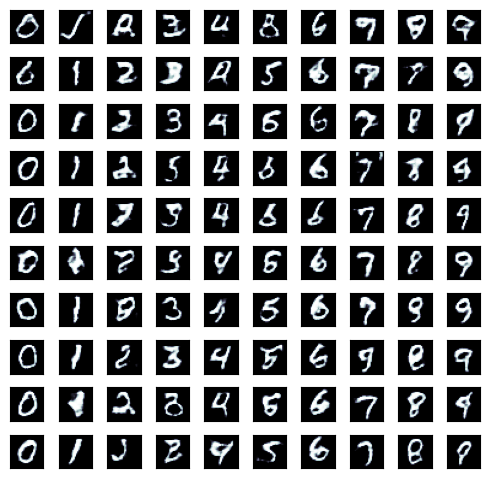

Epoch: 80 Loss D.: 0.5214939117431641
Epoch: 80 Loss G.: 1.5392398834228516  
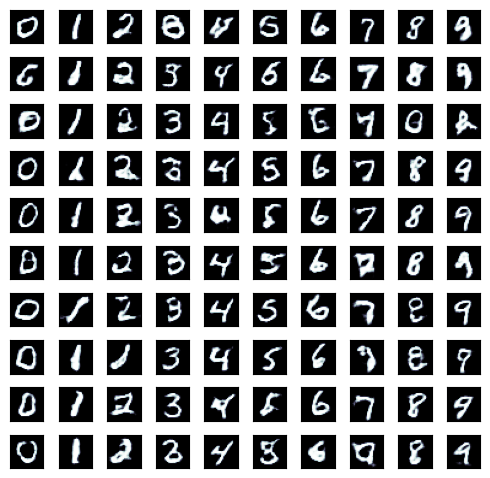

Epoch: 90 Loss D.: 0.571368932723999
Epoch: 90 Loss G.: 1.155524730682373  

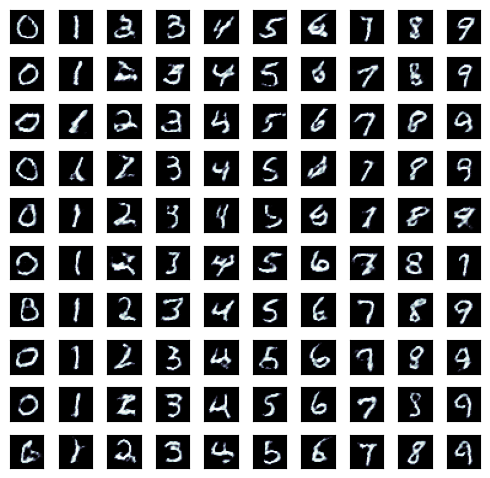> 들여쓴 블록



### Model save&load

In [ ]:
# # # gdriver mount to load saved model
# save_path='/content/models/PT/'

Mounted at ./gdrive


In [ ]:
# torch.save(discriminator, save_path+'cgan_discriminator.pt')
# torch.save(generator, save_path+'cgan_generator.pt')

In [ ]:
# discriminator = torch.load(save_path+'cgan_discriminator.pt')
# generator = torch.load(save_path+'cgan_generator.pt')

-  Generator model을 load하여 원하는 글자 생성하기

In [ ]:
r, c = 10, 10
fig = plt.figure(figsize=(6,6))
plt.subplots_adjust(top=1, bottom=0, hspace=0, wspace=0.05)
#fig, axs = plt.subplots(r, c)
for i in range(c):
    sampled_noise, _ = generator_input(c) # Fake label은 버리고
    # 0~9 까지 새로운 label생성
    new_label = np.eye(r, 10)[
          np.full(fill_value=i, shape=(r))] # 10개씩 준비
        # z와 new_label 10개를 입력으로 이미지 추론
    gen_imgs = generator(sampled_noise.to(device), torch.Tensor(new_label).to(device))
    gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
    for j in range(r):
        ax = fig.add_subplot(r, c, j * r + i + 1)
        ax.imshow(gen_imgs.cpu().detach().numpy()[j,0, :, :], cmap=plt.cm.bone)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
plt.tight_layout()
plt.show()

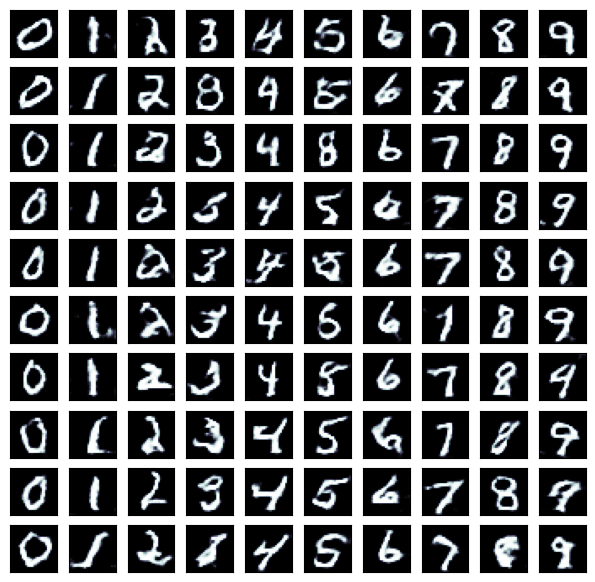